# 🥊 ML-AI Motion Controller - Model Training

**Version 2.0** - Pro-Level Features (108) with Data Augmentation & GridSearchCV

---

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Setup Path
sys.path.insert(0, os.path.abspath(".."))
import src.config as config
from src.data.processing import transform_dataset, video_based_split
from src.data.augmentation import augment_dataset

print("✓ Libraries loaded (with video_based_split)")

✓ Libraries loaded (with video_based_split)


## 1. Configuration

In [2]:
# Training Settings
USE_AUGMENTATION = True
USE_GRID_SEARCH = True

print(f"Dataset Dir: {config.DATASET_DIR}")
print(f"Models Dir: {config.MODELS_DIR}")
print(f"Total Features: {config.TOTAL_FEATURES}")

Dataset Dir: d:\ML-AI Motion Controller\dataset
Models Dir: d:\ML-AI Motion Controller\models
Total Features: 108


## 2. Data Loading

In [3]:
data_dir = os.path.join(config.DATASET_DIR, "by_class")
dfs = []

if os.path.exists(data_dir):
    csv_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
    for file in csv_files:
        file_path = os.path.join(data_dir, file)
        try:
            df_raw = pd.read_csv(file_path).dropna()
            df_pro = transform_dataset(df_raw)
            dfs.append(df_pro)
            print(f"✓ Loaded {file}: {len(df_pro)} samples")
        except Exception as e:
            print(f"❌ Error: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"\n📊 Total: {len(df)} samples")

✓ Loaded block.csv: 500 samples
✓ Loaded dodge_back.csv: 300 samples
✓ Loaded dodge_front.csv: 300 samples
✓ Loaded dodge_left.csv: 300 samples
✓ Loaded dodge_right.csv: 300 samples
✓ Loaded final_skill.csv: 300 samples
✓ Loaded left_punch.csv: 300 samples
✓ Loaded neutral.csv: 500 samples
✓ Loaded right_punch.csv: 300 samples

📊 Total: 3100 samples


## 3. Data Augmentation

✓ Augmented: 3100 → 6200 samples


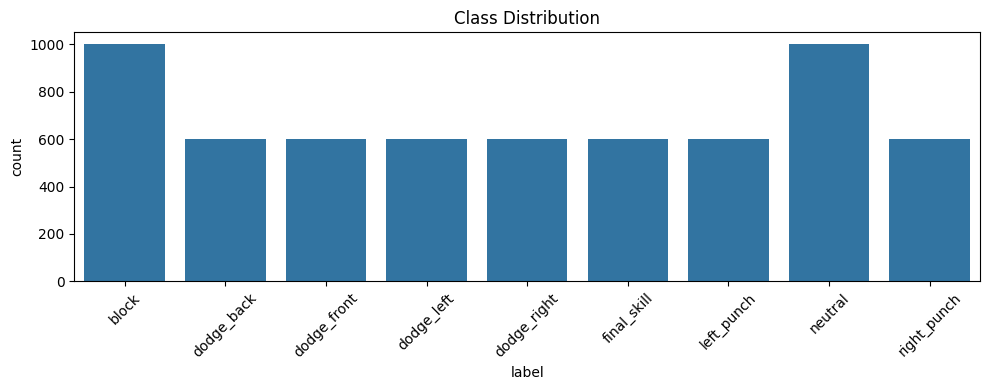

In [4]:
if USE_AUGMENTATION:
    original_size = len(df)
    df = augment_dataset(df, augment_factor=1, noise_level=0.02)  # 1 = 2x augmentation (original + 1 copy)
    print(f"✓ Augmented: {original_size} → {len(df)} samples")

# Class Distribution
plt.figure(figsize=(10, 4))
sns.countplot(x="label", data=df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Data Splitting

In [5]:
X = df.iloc[:, :-1].values
y = df["label"].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use VIDEO-BASED SPLIT to prevent data leakage
print('\n⚠️  Using VIDEO-BASED SPLIT (no data leakage)')
X_train, X_val, X_test, y_train, y_val, y_test = video_based_split(
    X_scaled, y_encoded, test_size=0.15, val_size=0.15, chunk_size=50, random_state=99
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print('✓ Honest train/val/test split completed')


⚠️  Using VIDEO-BASED SPLIT (no data leakage)
Train: 4900 | Val: 650 | Test: 650
✓ Honest train/val/test split completed


## 5. Model Training

In [6]:
if USE_GRID_SEARCH:
    param_grid = {
        "hidden_layer_sizes": [(128, 64), (256, 128), (256, 128, 64)],
        "alpha": [0.0001, 0.001],
        "learning_rate_init": [0.001, 0.0005]
    }
    
    base_model = MLPClassifier(
        activation="relu", solver="adam", max_iter=500,
        early_stopping=True, random_state=42, verbose=False
    )
    
    grid_search = GridSearchCV(base_model, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    
    print(f"\n✅ Best Parameters: {grid_search.best_params_}")
    print(f"✅ Best CV Score: {grid_search.best_score_*100:.2f}%")
    best_model = grid_search.best_estimator_
else:
    best_model = MLPClassifier(
        hidden_layer_sizes=(128, 64), activation="relu", solver="adam",
        alpha=0.0001, learning_rate_init=0.001, max_iter=500,
        early_stopping=True, verbose=True, random_state=42
    )
    best_model.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Best Parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
✅ Best CV Score: 98.96%


## 6. Evaluation

🏆 Test Accuracy: 98.62%

Classification Report:
              precision    recall  f1-score   support

       block       0.96      1.00      0.98       150
  dodge_back       1.00      1.00      1.00        50
 dodge_front       1.00      0.94      0.97        50
  dodge_left       0.96      1.00      0.98        50
 dodge_right       0.98      1.00      0.99        50
 final_skill       1.00      1.00      1.00        50
  left_punch       1.00      1.00      1.00        50
     neutral       1.00      0.96      0.98       150
 right_punch       1.00      1.00      1.00        50

    accuracy                           0.99       650
   macro avg       0.99      0.99      0.99       650
weighted avg       0.99      0.99      0.99       650



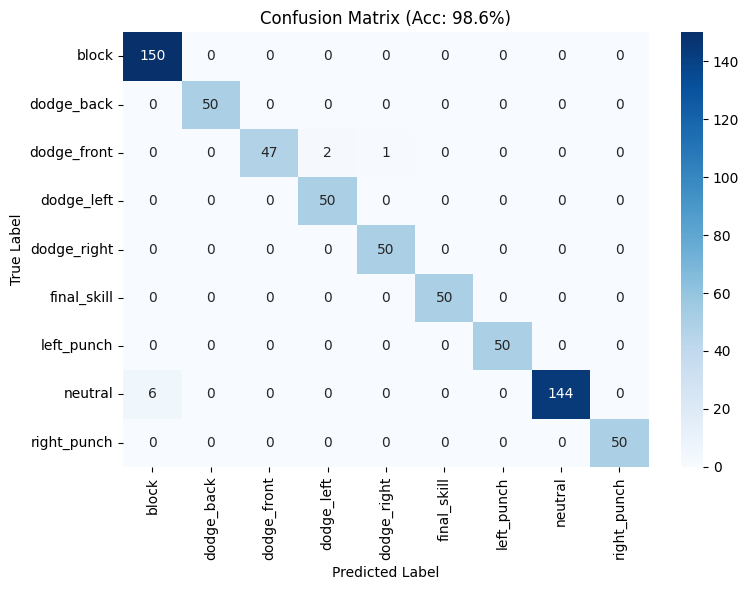

In [7]:
y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f"🏆 Test Accuracy: {test_acc*100:.2f}%")
print("\nClassification Report:")
# Get unique labels in test set
unique_labels = np.unique(np.concatenate([y_test, y_pred]))
target_names = encoder.inverse_transform(unique_labels)
print(classification_report(y_test, y_pred, labels=unique_labels, target_names=target_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.title(f"Confusion Matrix (Acc: {test_acc*100:.1f}%)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 7. Save Model

In [8]:
config.ensure_directories()

with open(config.MODEL_FILE, "wb") as f:
    pickle.dump(best_model, f)
with open(config.ENCODER_FILE, "wb") as f:
    pickle.dump(encoder, f)
with open(config.SCALER_FILE, "wb") as f:
    pickle.dump(scaler, f)

print(f"✅ Model saved: {config.MODEL_FILE}")
print(f"✅ Encoder saved: {config.ENCODER_FILE}")
print(f"✅ Scaler saved: {config.SCALER_FILE}")
print(f"\n🎉 TRAINING COMPLETE! Accuracy: {test_acc*100:.2f}%")

✓ Directories ready: d:\ML-AI Motion Controller\dataset, d:\ML-AI Motion Controller\models
✅ Model saved: d:\ML-AI Motion Controller\models\boxing_model.pkl
✅ Encoder saved: d:\ML-AI Motion Controller\models\label_encoder.pkl
✅ Scaler saved: d:\ML-AI Motion Controller\models\scaler.pkl

🎉 TRAINING COMPLETE! Accuracy: 98.62%
